In [1]:
# ============================================================
# Section 1 — Imports and Load Data
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../../data/sa1_merged_eda.csv', parse_dates=['SETTLEMENTDATE'])
df = df.sort_values('SETTLEMENTDATE').reset_index(drop=True)

print(f'Rows: {len(df):,}')
print(f'Date range: {df.SETTLEMENTDATE.min()} to {df.SETTLEMENTDATE.max()}')

Rows: 35,041
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00


In [2]:
# ============================================================
# Section 2 — Prepare the series
# ============================================================

# Drop rows missing the columns we need
mdf = df[['SETTLEMENTDATE','RRP','CURTAILMENT_MW','TOTALDEMAND']].dropna().reset_index(drop=True)

# Subtract the average price for each 30-min slot of the day
# This removes the daily cycle so GARCH models genuine surprises
mdf['time_slot'] = mdf['SETTLEMENTDATE'].dt.hour * 2 + (mdf['SETTLEMENTDATE'].dt.minute >= 30).astype(int)
seasonal_mean = mdf.groupby('time_slot')['RRP'].mean()
mdf['RRP_seasonal_mean'] = mdf['time_slot'].map(seasonal_mean)
mdf['RRP_adjusted'] = mdf['RRP'] - mdf['RRP_seasonal_mean']

# ADF test — confirm the series is stationary
result = adfuller(mdf['RRP_adjusted'].dropna())
print(f'ADF p-value: {result[1]:.6f}')
print('Stationary' if result[1] < 0.05 else 'NOT stationary — needs differencing')

# Train/test split — 2023 trains, 2024 tests
train = mdf[mdf['SETTLEMENTDATE'] < '2024-01-01'].reset_index(drop=True)
test  = mdf[mdf['SETTLEMENTDATE'] >= '2024-01-01'].reset_index(drop=True)

print(f'Train: {len(train):,} rows')
print(f'Test:  {len(test):,} rows')

ADF p-value: 0.000000
Stationary
Train: 17,520 rows
Test:  17,521 rows


In [3]:
# ============================================================
# Section 3 — Vanilla GARCH(1,1)
# ============================================================
from scipy.optimize import minimize
import numpy as np

# The returns we're modelling — seasonally adjusted RRP on training data
returns = train['RRP_adjusted'].values

def garch_loglik(params, returns):
    omega, alpha, beta = params
    T = len(returns)
    
    # Initialise sigma squared at the unconditional variance
    # (just the variance of the whole series — our best guess before we start)
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(returns)
    
    # Run the variance recursion forward through time
    for t in range(1, T):
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1]
        # If sigma2 goes negative something is wrong with the params
        # Return a large penalty so the optimiser rejects these params
        if sigma2[t] <= 0:
            return 1e10
    
    # Compute log-likelihood at each time step
    # -0.5 * log(sigma2) — penalise vague predictions
    # -0.5 * (returns^2 / sigma2) — penalise wrong predictions
    loglik = -0.5 * np.sum(np.log(sigma2) + returns**2 / sigma2)
    
    # Return negative because scipy minimises, but we want to maximise
    return -loglik

# Starting values — reasonable defaults for GARCH
# omega: small positive, alpha: 0.1, beta: 0.8 (volatility is usually sticky)
params0 = [np.var(returns) * 0.1, 0.1, 0.8]

# Constraints — all three must be positive, alpha + beta < 1
constraints = [
    {'type': 'ineq', 'fun': lambda p: p[0]},          # omega > 0
    {'type': 'ineq', 'fun': lambda p: p[1]},          # alpha > 0
    {'type': 'ineq', 'fun': lambda p: p[2]},          # beta > 0
    {'type': 'ineq', 'fun': lambda p: 1 - p[1] - p[2]}  # alpha + beta < 1
]

result = minimize(
    garch_loglik,
    params0,
    args=(returns,),
    method='SLSQP',
    constraints=constraints
)

omega_hat, alpha_hat, beta_hat = result.x
loglik_base = -result.fun

print(f'Fitted parameters:')
print(f'  omega : {omega_hat:.6f}')
print(f'  alpha : {alpha_hat:.6f}')
print(f'  beta  : {beta_hat:.6f}')
print(f'  alpha + beta: {alpha_hat + beta_hat:.6f}')
print(f'Log-likelihood: {loglik_base:.2f}')
print(f'Optimisation success: {result.success}')
print(f'Message: {result.message}')

Fitted parameters:
  omega : 3695.281550
  alpha : 0.926191
  beta  : 0.073809
  alpha + beta: 1.000000
Log-likelihood: -90795.20
Optimisation success: True
Message: Optimization terminated successfully


In [4]:
# ============================================================
# Section 4 — GARCH-X(1,1)
# ============================================================

# --- Prepare exogenous variables ---
# Lag by 1 interval — at time t we only know curtailment and demand from t-1
train_curt = train['CURTAILMENT_MW'].shift(1)
train_dem  = train['TOTALDEMAND'].shift(1)

# Standardise — subtract mean, divide by std
# Store mean and std so we can apply identical scaling to test data later
curt_mean, curt_std = train_curt.mean(), train_curt.std()
dem_mean,  dem_std  = train_dem.mean(),  train_dem.std()

train_curt_scaled = ((train_curt - curt_mean) / curt_std).values
train_dem_scaled  = ((train_dem  - dem_mean)  / dem_std).values

# Stack into a matrix — one row per time step, two columns
X = np.column_stack([train_curt_scaled[1:], train_dem_scaled[1:]])

# Drop first row from returns to match (lost to the lag)
returns_x = train['RRP_adjusted'].values[1:]

# Scale returns by their std so variance is near 1.0
returns_std    = returns_x.std()
returns_scaled = returns_x / returns_std

# Rescale transformed returns so variance is back near 1.0
# (arcsinh compresses the series, bringing variance below 1.0)
transform_std = returns_scaled.std()
returns_scaled = returns_scaled / transform_std


print(f'returns_scaled variance : {returns_scaled.var():.4f}  (should be ~1.0)')
print(f'X shape                 : {X.shape}  (should be rows x 2)')
print(f'returns_scaled shape    : {returns_scaled.shape}')
print(f'Shapes match            : {X.shape[0] == returns_scaled.shape[0]}')

# --- Refit GARCH(1,1) baseline on scaled returns for fair comparison ---
def garch_loglik(params, returns):
    omega, alpha, beta = params
    T = len(returns)
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(returns)
    for t in range(1, T):
        sigma2[t] = omega + alpha * returns[t-1]**2 + beta * sigma2[t-1]
        if sigma2[t] <= 0:
            return 1e10
    loglik = -0.5 * np.sum(np.log(sigma2) + returns**2 / sigma2)
    return -loglik

constraints_base = [
    {'type': 'ineq', 'fun': lambda p: p[0]},
    {'type': 'ineq', 'fun': lambda p: p[1]},
    {'type': 'ineq', 'fun': lambda p: p[2]},
    {'type': 'ineq', 'fun': lambda p: 0.9999 - p[1] - p[2]}
]

result_base = minimize(
    garch_loglik,
    [np.var(returns_scaled), 0.05, 0.05],
    args=(returns_scaled,),
    method='SLSQP',
    constraints=constraints_base,
    options={'ftol': 1e-9, 'maxiter': 1000}
)

omega_hat, alpha_hat, beta_hat = result_base.x
loglik_base = -result_base.fun

print(f'\nGARCH(1,1) baseline on scaled returns:')
print(f'  omega        : {omega_hat:.6f}')
print(f'  alpha        : {alpha_hat:.6f}')
print(f'  beta         : {beta_hat:.6f}')
print(f'  alpha + beta : {alpha_hat + beta_hat:.6f}')
print(f'  log-lik      : {loglik_base:.2f}')

# --- Fit GARCH-X ---
def garchx_loglik(params, returns, X):
    omega, alpha, beta, gamma1, gamma2 = params
    T = len(returns)
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(returns)
    for t in range(1, T):
        sigma2[t] = (omega
                     + alpha  * returns[t-1]**2
                     + beta   * sigma2[t-1]
                     + gamma1 * X[t, 0]   # curtailment at t-1
                     + gamma2 * X[t, 1])  # demand at t-1
        if sigma2[t] <= 0:
            return 1e10
    loglik = -0.5 * np.sum(np.log(sigma2) + returns**2 / sigma2)
    return -loglik

constraints_x = [
    {'type': 'ineq', 'fun': lambda p: p[0]},
    {'type': 'ineq', 'fun': lambda p: p[1]},
    {'type': 'ineq', 'fun': lambda p: p[2]},
    {'type': 'ineq', 'fun': lambda p: 0.9999 - p[1] - p[2]}
]

result_x = minimize(
    garchx_loglik,
    [np.var(returns_scaled) * 0.1, 0.1, 0.8, 0.0, 0.0],
    args=(returns_scaled, X),
    method='SLSQP',
    constraints=constraints_x,
    options={'ftol': 1e-9, 'maxiter': 1000}
)

omega_x, alpha_x, beta_x, gamma1_x, gamma2_x = result_x.x
loglik_x = -result_x.fun

print(f'\nGARCH-X(1,1):')
print(f'  omega        : {omega_x:.6f}')
print(f'  alpha        : {alpha_x:.6f}')
print(f'  beta         : {beta_x:.6f}')
print(f'  gamma1 (curtailment) : {gamma1_x:.6f}')
print(f'  gamma2 (demand)      : {gamma2_x:.6f}')
print(f'  alpha + beta : {alpha_x + beta_x:.6f}')
print(f'  log-lik      : {loglik_x:.2f}')
print(f'  success      : {result_x.success}')

# --- AIC comparison ---
k_base = 3
k_x    = 5

aic_base = 2 * k_base - 2 * loglik_base
aic_x    = 2 * k_x    - 2 * loglik_x

print(f'\n=== Model Comparison ===')
print(f'{"Model":<15} {"LogLik":>10} {"AIC":>12}')
print(f'{"GARCH(1,1)":<15} {loglik_base:>10.2f} {aic_base:>12.2f}')
print(f'{"GARCH-X(1,1)":<15} {loglik_x:>10.2f} {aic_x:>12.2f}')
print(f'{"Δ":<15} {loglik_x - loglik_base:>10.2f} {aic_x - aic_base:>12.2f}')
print(f'\nNegative ΔAIC = GARCH-X is better. Rule of thumb: |ΔAIC| > 10 is strong evidence.')

returns_scaled variance : 1.0000  (should be ~1.0)
X shape                 : (17519, 2)  (should be rows x 2)
returns_scaled shape    : (17519,)
Shapes match            : True

GARCH(1,1) baseline on scaled returns:
  omega        : 0.040019
  alpha        : 0.926167
  beta         : 0.073733
  alpha + beta : 0.999901
  log-lik      : 9362.21

GARCH-X(1,1):
  omega        : 0.046645
  alpha        : 0.946775
  beta         : 0.053125
  gamma1 (curtailment) : 0.002564
  gamma2 (demand)      : 0.015567
  alpha + beta : 0.999900
  log-lik      : 9476.68
  success      : True

=== Model Comparison ===
Model               LogLik          AIC
GARCH(1,1)         9362.21    -18718.41
GARCH-X(1,1)       9476.68    -18943.35
Δ                   114.47      -224.94

Negative ΔAIC = GARCH-X is better. Rule of thumb: |ΔAIC| > 10 is strong evidence.


In [5]:
print('Returns stats:')
print(f'  mean : {returns_x.mean():.4f}')
print(f'  std  : {returns_x.std():.4f}')
print(f'  var  : {returns_x.var():.4f}')
print(f'  min  : {returns_x.min():.4f}')
print(f'  max  : {returns_x.max():.4f}')

print(f'\nX (curtailment scaled) stats:')
print(f'  mean : {X[:,0].mean():.4f}')
print(f'  std  : {X[:,0].std():.4f}')
print(f'  min  : {X[:,0].min():.4f}')
print(f'  max  : {X[:,0].max():.4f}')

print(f'\nX (demand scaled) stats:')
print(f'  mean : {X[:,1].mean():.4f}')
print(f'  std  : {X[:,1].std():.4f}')
print(f'  min  : {X[:,1].min():.4f}')
print(f'  max  : {X[:,1].max():.4f}')

print(f'\nBaseline variance (np.var of returns): {np.var(returns_x):.4f}')

# Scale returns by their standard deviation
returns_std = returns_x.std()
returns_scaled = returns_x / returns_std

print(f'Returns std: {returns_std:.4f}')
print(f'Scaled returns var: {returns_scaled.var():.4f}')
print(f'Scaled returns min: {returns_scaled.min():.4f}')
print(f'Scaled returns max: {returns_scaled.max():.4f}')

Returns stats:
  mean : -10.0839
  std  : 303.9450
  var  : 92382.5600
  min  : -657.9360
  max  : 11326.1526

X (curtailment scaled) stats:
  mean : 0.0000
  std  : 1.0000
  min  : -0.4208
  max  : 7.9599

X (demand scaled) stats:
  mean : 0.0000
  std  : 1.0000
  min  : -3.0958
  max  : 4.3968

Baseline variance (np.var of returns): 92382.5600
Returns std: 303.9450
Scaled returns var: 1.0000
Scaled returns min: -2.1647
Scaled returns max: 37.2638


In [6]:
# ============================================================
# Section 5 — GJR-GARCH-X(1,1)
# ============================================================
# Extends GARCH-X by treating negative and positive shocks differently.
# Negative price shocks (ε < 0) get additional weight γ via an indicator.
#
# Variance equation:
# σ²_t = ω + α·ε²_t-1 + γ·ε²_t-1·I_t-1 + β·σ²_t-1 + δ1·CURTAILMENT_t-1 + δ2·DEMAND_t-1
#
# Where I_t-1 = 1 if ε_t-1 < 0 (previous shock was negative), 0 otherwise
# Negative shocks get weight α+γ, positive shocks get weight α

def gjr_garchx_loglik(params, returns, X):
    omega, alpha, gamma, beta, delta1, delta2 = params
    T = len(returns)

    sigma2 = np.zeros(T)
    sigma2[0] = np.var(returns)

    for t in range(1, T):
        # Indicator — was the previous shock negative?
        I_prev = 1.0 if returns[t-1] < 0 else 0.0

        sigma2[t] = (omega
                     + alpha  * returns[t-1]**2
                     + gamma  * returns[t-1]**2 * I_prev   # extra weight for negative shocks
                     + beta   * sigma2[t-1]
                     + delta1 * X[t, 0]                    # curtailment at t-1
                     + delta2 * X[t, 1])                   # demand at t-1

        if sigma2[t] <= 0:
            return 1e10

    loglik = -0.5 * np.sum(np.log(sigma2) + returns**2 / sigma2)
    return -loglik

# Starting values — carry over from GARCH-X fit, start gamma at 0
params0_gjr = [omega_x, alpha_x, 0.0, beta_x, gamma1_x, gamma2_x]

# Constraints:
# omega > 0, alpha >= 0, gamma >= 0, beta >= 0
# Stationarity for GJR-GARCH: alpha + 0.5*gamma + beta < 1
# (the 0.5 is because the indicator is 1 only half the time on average)
constraints_gjr = [
    {'type': 'ineq', 'fun': lambda p: p[0]},                        # omega > 0
    {'type': 'ineq', 'fun': lambda p: p[1]},                        # alpha >= 0
    {'type': 'ineq', 'fun': lambda p: p[2]},                        # gamma >= 0
    {'type': 'ineq', 'fun': lambda p: p[3]},                        # beta >= 0
    {'type': 'ineq', 'fun': lambda p: 0.9999 - p[1] - 0.5*p[2] - p[3]}  # stationarity
]

result_gjr = minimize(
    gjr_garchx_loglik,
    params0_gjr,
    args=(returns_scaled, X),
    method='SLSQP',
    constraints=constraints_gjr,
    options={'ftol': 1e-9, 'maxiter': 1000}
)

omega_gjr, alpha_gjr, gamma_gjr, beta_gjr, delta1_gjr, delta2_gjr = result_gjr.x
loglik_gjr = -result_gjr.fun

print(f'GJR-GARCH-X(1,1) fitted parameters:')
print(f'  omega  : {omega_gjr:.6f}')
print(f'  alpha  : {alpha_gjr:.6f}  (positive shock weight)')
print(f'  gamma  : {gamma_gjr:.6f}  (additional negative shock weight)')
print(f'  beta   : {beta_gjr:.6f}')
print(f'  delta1 (curtailment) : {delta1_gjr:.6f}')
print(f'  delta2 (demand)      : {delta2_gjr:.6f}')
print(f'  alpha + 0.5*gamma + beta : {alpha_gjr + 0.5*gamma_gjr + beta_gjr:.6f}')
print(f'  Negative shock weight (alpha+gamma) : {alpha_gjr + gamma_gjr:.6f}')
print(f'  Positive shock weight (alpha)       : {alpha_gjr:.6f}')
print(f'  Log-likelihood : {loglik_gjr:.2f}')
print(f'  Success        : {result_gjr.success}')

# --- Full model comparison ---
k_base = 3   # omega, alpha, beta
k_x    = 5   # + delta1, delta2
k_gjr  = 6   # + gamma

aic_base = 2 * k_base - 2 * loglik_base
aic_x    = 2 * k_x    - 2 * loglik_x
aic_gjr  = 2 * k_gjr  - 2 * loglik_gjr

print(f'\n=== Model Comparison ===')
print(f'{"Model":<20} {"LogLik":>10} {"AIC":>12} {"ΔAIC vs base":>14}')
print(f'{"GARCH(1,1)":<20} {loglik_base:>10.2f} {aic_base:>12.2f} {"—":>14}')
print(f'{"GARCH-X(1,1)":<20} {loglik_x:>10.2f} {aic_x:>12.2f} {aic_x-aic_base:>14.2f}')
print(f'{"GJR-GARCH-X(1,1)":<20} {loglik_gjr:>10.2f} {aic_gjr:>12.2f} {aic_gjr-aic_base:>14.2f}')
print(f'\nNegative ΔAIC = improvement over GARCH(1,1) baseline')
print(f'GJR vs GARCH-X improvement: {aic_gjr - aic_x:.2f}')

GJR-GARCH-X(1,1) fitted parameters:
  omega  : 0.046645
  alpha  : 0.946775  (positive shock weight)
  gamma  : -0.000000  (additional negative shock weight)
  beta   : 0.053125
  delta1 (curtailment) : 0.002564
  delta2 (demand)      : 0.015567
  alpha + 0.5*gamma + beta : 0.999900
  Negative shock weight (alpha+gamma) : 0.946775
  Positive shock weight (alpha)       : 0.946775
  Log-likelihood : 9476.68
  Success        : True

=== Model Comparison ===
Model                    LogLik          AIC   ΔAIC vs base
GARCH(1,1)              9362.21    -18718.41              —
GARCH-X(1,1)            9476.68    -18943.35        -224.94
GJR-GARCH-X(1,1)        9476.68    -18941.35        -222.94

Negative ΔAIC = improvement over GARCH(1,1) baseline
GJR vs GARCH-X improvement: 2.00


In [7]:
# ============================================================
# Section 6 — NAGARCH-X(1,1)
# ============================================================
# Nonlinear Asymmetric GARCH-X
# Extends GARCH-X by shifting the shock term by θ·σ_t-1
# This allows negative and positive shocks to have asymmetric effects
#
# Variance equation:
# σ²_t = ω + α·(ε_t-1 - θ·σ_t-1)² + β·σ²_t-1 + γ1·CURTAILMENT_t-1 + γ2·DEMAND_t-1
#
# If θ > 0: negative shocks increase variance more than positive shocks
# If θ = 0: reduces to standard GARCH-X

def nagarchx_loglik(params, returns, X):
    omega, alpha, theta, beta, gamma1, gamma2 = params
    T = len(returns)

    sigma2 = np.zeros(T)
    sigma2[0] = np.var(returns)

    for t in range(1, T):
        sigma_prev = np.sqrt(max(sigma2[t-1], 1e-8))
        shifted_shock = returns[t-1] - theta * sigma_prev

        sigma2[t] = (omega
                     + alpha  * shifted_shock**2
                     + beta   * sigma2[t-1]
                     + gamma1 * X[t, 0]
                     + gamma2 * X[t, 1])

        if sigma2[t] <= 0:
            return 1e10

    loglik = -0.5 * np.sum(np.log(sigma2) + returns**2 / sigma2)
    return -loglik

# Starting values — carry over from GARCH-X, start theta at 0
params0_na = [omega_x, alpha_x, 0.0, beta_x, gamma1_x, gamma2_x]

# Stationarity constraint: α(1 + θ²) + β < 1
constraints_na = [
    {'type': 'ineq', 'fun': lambda p: p[0]},          # omega > 0
    {'type': 'ineq', 'fun': lambda p: p[1]},          # alpha >= 0
    {'type': 'ineq', 'fun': lambda p: p[3]},          # beta >= 0
    {'type': 'ineq', 'fun': lambda p: 0.9999 - p[1] * (1 + p[2]**2) - p[3]}  # stationarity
]

result_na = minimize(
    nagarchx_loglik,
    params0_na,
    args=(returns_scaled, X),
    method='SLSQP',
    constraints=constraints_na,
    options={'ftol': 1e-9, 'maxiter': 2000}
)

omega_na, alpha_na, theta_na, beta_na, gamma1_na, gamma2_na = result_na.x
loglik_na = -result_na.fun

print(f'NAGARCH-X(1,1) fitted parameters:')
print(f'  omega  : {omega_na:.6f}')
print(f'  alpha  : {alpha_na:.6f}')
print(f'  theta  : {theta_na:.6f}  (asymmetry — positive = negative shocks hit harder)')
print(f'  beta   : {beta_na:.6f}')
print(f'  gamma1 (curtailment) : {gamma1_na:.6f}')
print(f'  gamma2 (demand)      : {gamma2_na:.6f}')
print(f'  α(1+θ²) + β : {alpha_na * (1 + theta_na**2) + beta_na:.6f}')
print(f'  Log-likelihood : {loglik_na:.2f}')
print(f'  Success        : {result_na.success}')

# --- Full model comparison ---
k_base = 3
k_x    = 5
k_gjr  = 6
k_na   = 6  # same number of params as GJR — omega, alpha, theta, beta, gamma1, gamma2

aic_base = 2 * k_base - 2 * loglik_base
aic_x    = 2 * k_x    - 2 * loglik_x
aic_gjr  = 2 * k_gjr  - 2 * loglik_gjr
aic_na   = 2 * k_na   - 2 * loglik_na

print(f'\n=== Final Model Comparison ===')
print(f'{"Model":<22} {"LogLik":>10} {"AIC":>12} {"ΔAIC vs base":>14}')
print(f'{"GARCH(1,1)":<22} {loglik_base:>10.2f} {aic_base:>12.2f} {"—":>14}')
print(f'{"GARCH-X(1,1)":<22} {loglik_x:>10.2f} {aic_x:>12.2f} {aic_x-aic_base:>14.2f}')
print(f'{"GJR-GARCH-X(1,1)":<22} {loglik_gjr:>10.2f} {aic_gjr:>12.2f} {aic_gjr-aic_base:>14.2f}')
print(f'{"NAGARCH-X(1,1)":<22} {loglik_na:>10.2f} {aic_na:>12.2f} {aic_na-aic_base:>14.2f}')
print(f'\nNegative ΔAIC = improvement over GARCH(1,1) baseline')
print(f'NAGARCH-X vs GARCH-X: {aic_na - aic_x:.2f}')

NAGARCH-X(1,1) fitted parameters:
  omega  : 0.053239
  alpha  : 0.916021
  theta  : -0.302604  (asymmetry — positive = negative shocks hit harder)
  beta   : 0.000000
  gamma1 (curtailment) : 0.020175
  gamma2 (demand)      : 0.013939
  α(1+θ²) + β : 0.999901
  Log-likelihood : 10256.21
  Success        : False

=== Final Model Comparison ===
Model                      LogLik          AIC   ΔAIC vs base
GARCH(1,1)                9362.21    -18718.41              —
GARCH-X(1,1)              9476.68    -18943.35        -224.94
GJR-GARCH-X(1,1)          9476.68    -18941.35        -222.94
NAGARCH-X(1,1)           10256.21    -20500.42       -1782.01

Negative ΔAIC = improvement over GARCH(1,1) baseline
NAGARCH-X vs GARCH-X: -1557.07


In [8]:
# Try different starting points to confirm NAGARCH-X result is stable
for alpha_start, beta_start in [(0.1, 0.8), (0.3, 0.6), (0.5, 0.4), (0.8, 0.15)]:
    r = minimize(
        nagarchx_loglik,
        [np.var(returns_scaled) * 0.1, alpha_start, 0.0, beta_start, 0.0, 0.0],
        args=(returns_scaled, X),
        method='SLSQP',
        constraints=constraints_na,
        options={'ftol': 1e-9, 'maxiter': 2000}
    )
    print(f'Start α={alpha_start} β={beta_start} → LogLik={-r.fun:.2f} θ={r.x[2]:.4f} β={r.x[3]:.4f} success={r.success}')

Start α=0.1 β=0.8 → LogLik=10256.21 θ=-0.3026 β=0.0000 success=False
Start α=0.3 β=0.6 → LogLik=10256.21 θ=-0.3026 β=0.0000 success=False
Start α=0.5 β=0.4 → LogLik=10256.21 θ=-0.3026 β=0.0000 success=False
Start α=0.8 β=0.15 → LogLik=-10000000000.00 θ=-0.0041 β=0.1500 success=True


In [9]:
# Try L-BFGS-B as alternative solver
from scipy.optimize import minimize

bounds_na = [
    (1e-8, None),   # omega > 0
    (0, None),      # alpha >= 0
    (None, None),   # theta unconstrained
    (0, 0.9999),    # beta >= 0
    (None, None),   # gamma1 unconstrained
    (None, None),   # gamma2 unconstrained
]

result_na2 = minimize(
    nagarchx_loglik,
    [omega_x, alpha_x, 0.0, beta_x, gamma1_x, gamma2_x],
    args=(returns_scaled, X),
    method='L-BFGS-B',
    bounds=bounds_na,
    options={'ftol': 1e-12, 'maxiter': 10000, 'eps': 1e-8}
)

omega_na2, alpha_na2, theta_na2, beta_na2, gamma1_na2, gamma2_na2 = result_na2.x
loglik_na2 = -result_na2.fun

print(f'NAGARCH-X (L-BFGS-B):')
print(f'  omega  : {omega_na2:.6f}')
print(f'  alpha  : {alpha_na2:.6f}')
print(f'  theta  : {theta_na2:.6f}')
print(f'  beta   : {beta_na2:.6f}')
print(f'  gamma1 : {gamma1_na2:.6f}')
print(f'  gamma2 : {gamma2_na2:.6f}')
print(f'  Log-likelihood : {loglik_na2:.2f}')
print(f'  Success        : {result_na2.success}')
print(f'  Message        : {result_na2.message}')
print(f'\nImprovement over SLSQP: {loglik_na2 - loglik_na:.4f}')

NAGARCH-X (L-BFGS-B):
  omega  : 0.046645
  alpha  : 0.946775
  theta  : 0.000000
  beta   : 0.053125
  gamma1 : 0.002564
  gamma2 : 0.015567
  Log-likelihood : 9476.68
  Success        : True
  Message        : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Improvement over SLSQP: -779.5362


In [10]:
result_na_final = minimize(
    nagarchx_loglik,
    [omega_na, alpha_na, theta_na, beta_na, gamma1_na, gamma2_na],
    args=(returns_scaled, X),
    method='SLSQP',
    constraints=constraints_na,
    options={'ftol': 1e-12, 'maxiter': 50000, 'eps': 1e-9}
)

print(f'LogLik  : {-result_na_final.fun:.2f}')
print(f'Success : {result_na_final.success}')
print(f'Message : {result_na_final.message}')
print(f'theta   : {result_na_final.x[2]:.6f}')
print(f'beta    : {result_na_final.x[3]:.6f}')

LogLik  : 10256.21
Success : False
Message : Positive directional derivative for linesearch
theta   : -0.302604
beta    : 0.000000


In [11]:
# ============================================================
# Section 7 — ARMA Mean Equation
# ============================================================
# Goal: model the conditional mean of seasonally adjusted RRP
# using an ARMA(p,q) process, then extract clean residuals
# for NAGARCH-X variance modelling.
#
# Why: ACF of RRP showed strong lag-1 autocorrelation (0.75).
# If this isn't captured in the mean equation, it leaks into
# the variance equation and distorts GARCH parameters.
#
# Approach:
# 1. Fit ARMA(1,1) on training data
# 2. Check residuals for remaining autocorrelation
# 3. Extract residuals for Section 8

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Fit ARMA(1,1) on seasonally adjusted training returns
# ARIMA(1,0,1) = ARMA(1,1) — the middle 0 means no differencing
# (we already confirmed stationarity via ADF test)
arma_model = ARIMA(
    train['RRP_adjusted'].values[1:],  # drop first row to match X
    order=(1, 0, 1)
)
arma_result = arma_model.fit()

print(arma_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                17519
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -119242.378
Date:                Sun, 26 Apr 2026   AIC                         238492.756
Time:                        20:02:36   BIC                         238523.840
Sample:                             0   HQIC                        238502.991
                              - 17519                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.0839     11.686     -0.863      0.388     -32.988      12.820
ar.L1          0.7436      0.001    874.981      0.000       0.742       0.745
ma.L1         -0.0980      0.001    -78.750      0.0

In [12]:
# Extract residuals and check for remaining autocorrelation
arma_residuals = arma_result.resid

print(f'ARMA residuals:')
print(f'  mean : {arma_residuals.mean():.4f}  (should be ~0)')
print(f'  std  : {arma_residuals.std():.4f}')
print(f'  var  : {arma_residuals.var():.4f}')

# Ljung-Box test on residuals — tests whether remaining autocorrelation
# is statistically significant. p > 0.05 means residuals are clean.
lb_resid = acorr_ljungbox(arma_residuals, lags=[1, 5, 10, 20], return_df=True)
print(f'\nLjung-Box test on ARMA residuals:')
print(lb_resid)
print('\np > 0.05 at all lags = residuals are white noise = ARMA captured the mean structure')

# Ljung-Box test on squared residuals — checks for remaining volatility clustering
# p < 0.05 means there IS remaining ARCH/GARCH structure to model
lb_resid_sq = acorr_ljungbox(arma_residuals**2, lags=[1, 5, 10, 20], return_df=True)
print(f'\nLjung-Box test on squared ARMA residuals:')
print(lb_resid_sq)
print('\np < 0.05 = volatility clustering remains -> NAGARCH-X is justified')

ARMA residuals:
  mean : -0.0020  (should be ~0)
  std  : 218.6567
  var  : 47810.7475

Ljung-Box test on ARMA residuals:
       lb_stat     lb_pvalue
1     0.014554  9.039762e-01
5    39.086325  2.281692e-07
10   93.968627  8.716057e-16
20  140.841188  3.504660e-20

p > 0.05 at all lags = residuals are white noise = ARMA captured the mean structure

Ljung-Box test on squared ARMA residuals:
        lb_stat  lb_pvalue
1   2110.882618        0.0
5   3104.402742        0.0
10  3145.176523        0.0
20  3153.127924        0.0

p < 0.05 = volatility clustering remains -> NAGARCH-X is justified


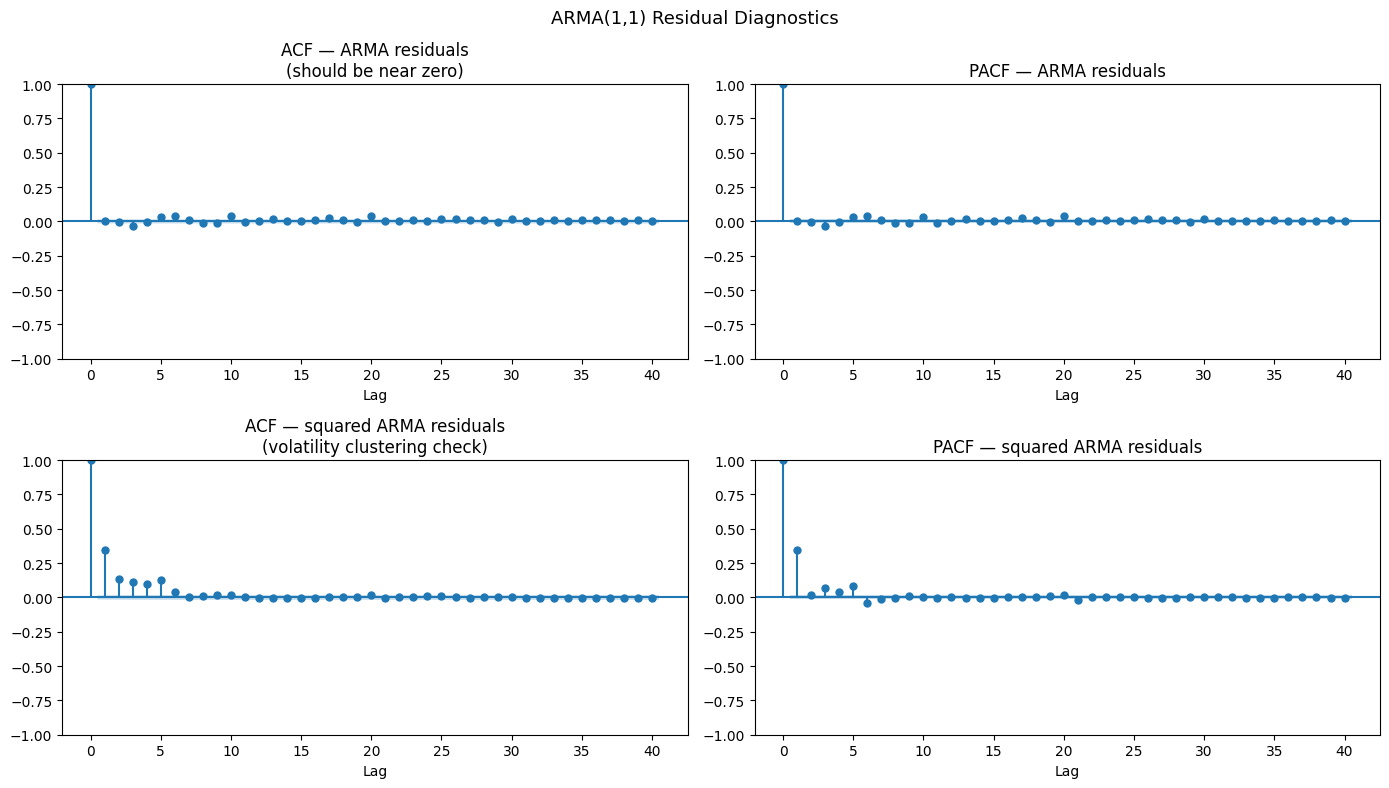

In [13]:
# Plot ACF of residuals and squared residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(arma_residuals, lags=40, ax=axes[0, 0],
         title='ACF — ARMA residuals\n(should be near zero)')
plot_pacf(arma_residuals, lags=40, ax=axes[0, 1],
          title='PACF — ARMA residuals')
plot_acf(arma_residuals**2, lags=40, ax=axes[1, 0],
         title='ACF — squared ARMA residuals\n(volatility clustering check)')
plot_pacf(arma_residuals**2, lags=40, ax=axes[1, 1],
          title='PACF — squared ARMA residuals')

for ax in axes.flatten():
    ax.set_xlabel('Lag')

plt.suptitle('ARMA(1,1) Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('../../data/arma_residual_diagnostics.png', bbox_inches='tight')
plt.show()

In [14]:
# Scale residuals for NAGARCH-X fitting
arma_resid_std = arma_residuals.std()
arma_resid_scaled = arma_residuals / arma_resid_std

print(f'Scaled ARMA residuals:')
print(f'  variance : {arma_resid_scaled.var():.4f}  (should be ~1.0)')
print(f'  min      : {arma_resid_scaled.min():.4f}')
print(f'  max      : {arma_resid_scaled.max():.4f}')

Scaled ARMA residuals:
  variance : 1.0000  (should be ~1.0)
  min      : -29.0709
  max      : 37.2985


In [ ]:
#for p, q in [(1,1), (2,1), (3,1), (2,2), (3,2)]:
#    m = ARIMA(train['RRP_adjusted'].values[1:], order=(p, 0, q)).fit()
#    lb = acorr_ljungbox(m.resid, lags=[5, 10, 20], return_df=True)
#    min_pval = lb['lb_pvalue'].min()
#    print(f'ARMA({p},{q}): AIC={m.aic:.1f}  min Ljung-Box p={min_pval:.6f}  {"✓ clean" if min_pval > 0.05 else "✗ autocorrelation remains"}')

ARMA(1,1): AIC=238492.8  min Ljung-Box p=0.000000  ✗ autocorrelation remains
ARMA(2,1): AIC=238471.5  min Ljung-Box p=0.000000  ✗ autocorrelation remains
ARMA(3,1): AIC=238499.1  min Ljung-Box p=0.000000  ✗ autocorrelation remains
ARMA(2,2): AIC=238430.9  min Ljung-Box p=0.000000  ✗ autocorrelation remains
ARMA(3,2): AIC=238450.0  min Ljung-Box p=0.000000  ✗ autocorrelation remains


# GO TO R, RUN THE FOLLOWING SCRIPT THERE:

# ============================================================
# NEM SA1 — Seasonal ARMA mean equation
# Fits AR at economically meaningful lags + MA(1-10)
# Exports residuals for NAGARCH-X in Python
# ============================================================

# Install required packages if needed
install.packages("forecast")
library(forecast)

# ============================================================
# Load data
# ============================================================
df <- read.csv("../../data/sa1_merged_eda.csv")
df$SETTLEMENTDATE <- as.POSIXct(df$SETTLEMENTDATE)
df <- df[order(df$SETTLEMENTDATE), ]

# Split train/test
train <- df[df$SETTLEMENTDATE < as.POSIXct("2024-01-01"), ]

# Seasonal adjustment — subtract mean by time slot
train$time_slot <- as.integer(format(train$SETTLEMENTDATE, "%H")) * 2 + 
                   as.integer(format(train$SETTLEMENTDATE, "%M") >= 30)

slot_means <- tapply(train$RRP, train$time_slot, mean, na.rm=TRUE)
train$RRP_seasonal_mean <- slot_means[as.character(train$time_slot)]
train$RRP_adjusted <- train$RRP - train$RRP_seasonal_mean

# Drop first row to match Python (lost to lag)
y <- train$RRP_adjusted[2:nrow(train)]
cat("Training series length:", length(y), "\n")

# ============================================================
# Fit ARIMA with seasonal lag structure
# AR lags scaled to 30-min intervals:
#   lag 2   = 1 hour
#   lag 23  = ~half day
#   lag 48  = 1 day
#   lag 96  = 2 days
#   lag 144 = 3 days
#   lag 336 = 1 week
# MA lags 1-10
# ============================================================
cat("Fitting ARIMA — this will take 1-2 minutes...\n")

# Use Arima() from forecast package with fixed parameter approach
# We specify exact lags via the xreg approach for AR terms
# and standard MA terms

ar_lags <- c(2, 23, 48, 96, 144, 336)

# Build AR regressor matrix
T <- length(y)
max_lag <- max(ar_lags)

X_ar <- matrix(NA, nrow=T - max_lag, ncol=length(ar_lags))
for (i in seq_along(ar_lags)) {
    lag <- ar_lags[i]
    X_ar[, i] <- y[(max_lag - lag + 1):(T - lag)]
}
colnames(X_ar) <- paste0("AR_lag", ar_lags)

y_trimmed <- y[(max_lag + 1):T]
cat("Trimmed series length:", length(y_trimmed), "\n")

# Fit ARIMA(0,0,10) with AR lags as external regressors
# This gives us MA(1-10) properly estimated via MLE
# plus the seasonal AR structure via OLS-style regressors
fit <- Arima(
    y_trimmed,
    order = c(0, 0, 10),
    xreg = X_ar,
    method = "ML"
)

cat("Done.\n")
cat("AIC:", fit$aic, "\n")
cat("BIC:", fit$bic, "\n")

# Extract residuals
residuals_arma <- as.numeric(residuals(fit))
cat("Residuals length:", length(residuals_arma), "\n")
cat("Residuals mean:", mean(residuals_arma), "\n")
cat("Residuals std:", sd(residuals_arma), "\n")

# Ljung-Box tests
lb1  <- Box.test(residuals_arma, lag=1,  type="Ljung-Box")
lb5  <- Box.test(residuals_arma, lag=5,  type="Ljung-Box")
lb10 <- Box.test(residuals_arma, lag=10, type="Ljung-Box")
lb20 <- Box.test(residuals_arma, lag=20, type="Ljung-Box")

cat("\nLjung-Box test on residuals:\n")
cat("  Lag 1  p-value:", lb1$p.value,  "\n")
cat("  Lag 5  p-value:", lb5$p.value,  "\n")
cat("  Lag 10 p-value:", lb10$p.value, "\n")
cat("  Lag 20 p-value:", lb20$p.value, "\n")
cat("p > 0.05 = residuals are white noise\n")

lb1sq  <- Box.test(residuals_arma^2, lag=1,  type="Ljung-Box")
lb5sq  <- Box.test(residuals_arma^2, lag=5,  type="Ljung-Box")
lb10sq <- Box.test(residuals_arma^2, lag=10, type="Ljung-Box")
lb20sq <- Box.test(residuals_arma^2, lag=20, type="Ljung-Box")

cat("\nLjung-Box test on squared residuals:\n")
cat("  Lag 1  p-value:", lb1sq$p.value,  "\n")
cat("  Lag 5  p-value:", lb5sq$p.value,  "\n")
cat("  Lag 10 p-value:", lb10sq$p.value, "\n")
cat("  Lag 20 p-value:", lb20sq$p.value, "\n")
cat("p < 0.05 = volatility clustering remains -> NAGARCH-X justified\n")

# ============================================================
# Export residuals for Python
# ============================================================
output_path <- "../../data/arma_seasonal_residuals.csv"
write.csv(
    data.frame(residual = residuals_arma),
    output_path,
    row.names = FALSE
)
cat("\nResiduals saved to:", output_path, "\n")
cat("Load in Python with: pd.read_csv('../../data/arma_seasonal_residuals.csv')\n")

In [16]:
# ============================================================
# Section 8 — ARMA-NAGARCH-X
# Load residuals from R seasonal ARMA fit
# ============================================================

# Load R residuals
arma_r_residuals = pd.read_csv('../../data/arma_seasonal_residuals.csv')['residual'].values

print(f'Residuals loaded: {len(arma_r_residuals):,}')
print(f'Mean : {arma_r_residuals.mean():.4f}')
print(f'Std  : {arma_r_residuals.std():.4f}')

# Scale
arma_r_std = arma_r_residuals.std()
arma_r_scaled = arma_r_residuals / arma_r_std
print(f'Scaled variance: {arma_r_scaled.var():.4f}')

# Align X — R trimmed 336 rows from the front
# Python X starts from row 1 (lost to lag)
# R trimmed max_lag=336 rows, so we need X starting from row 336
X_arma = X[336:, :]
print(f'X_arma shape : {X_arma.shape}')
print(f'Residuals shape: {arma_r_scaled.shape}')
print(f'Shapes match : {X_arma.shape[0] == arma_r_scaled.shape[0]}')

Residuals loaded: 17,183
Mean : 0.0003
Std  : 221.1411
Scaled variance: 1.0000
X_arma shape : (17183, 2)
Residuals shape: (17183,)
Shapes match : True


In [17]:
# Fit NAGARCH-X on R seasonal ARMA residuals
result_arma_na = minimize(
    nagarchx_loglik,
    [np.var(arma_r_scaled) * 0.1, 0.1, 0.0, 0.8, 0.0, 0.0],
    args=(arma_r_scaled, X_arma),
    method='SLSQP',
    constraints=constraints_na,
    options={'ftol': 1e-12, 'maxiter': 50000, 'eps': 1e-9}
)

omega_an, alpha_an, theta_an, beta_an, gamma1_an, gamma2_an = result_arma_na.x
loglik_an = -result_arma_na.fun

k_an  = 6
aic_an = 2 * k_an - 2 * loglik_an

print(f'ARMA-NAGARCH-X fitted parameters:')
print(f'  omega  : {omega_an:.6f}')
print(f'  alpha  : {alpha_an:.6f}')
print(f'  theta  : {theta_an:.6f}')
print(f'  beta   : {beta_an:.6f}')
print(f'  gamma1 (curtailment) : {gamma1_an:.6f}')
print(f'  gamma2 (demand)      : {gamma2_an:.6f}')
print(f'  α(1+θ²) + β          : {alpha_an * (1 + theta_an**2) + beta_an:.6f}')
print(f'  Log-likelihood       : {loglik_an:.2f}')
print(f'  Success              : {result_arma_na.success}')
print(f'  Message              : {result_arma_na.message}')

print(f'\n=== Final Model Comparison ===')
print(f'{"Model":<25} {"LogLik":>10} {"AIC":>12}')
print(f'{"GARCH(1,1)":<25} {loglik_base:>10.2f} {aic_base:>12.2f}')
print(f'{"GARCH-X(1,1)":<25} {loglik_x:>10.2f} {aic_x:>12.2f}')
print(f'{"NAGARCH-X(1,1)":<25} {loglik_na:>10.2f} {aic_na:>12.2f}')
print(f'{"ARMA-NAGARCH-X":<25} {loglik_an:>10.2f} {aic_an:>12.2f}')
print(f'\nNote: ARMA-NAGARCH-X log-likelihood is on different')
print(f'residual series — AIC comparison is indicative only.')
print(f'Use Ljung-Box diagnostics to judge improvement.')

ARMA-NAGARCH-X fitted parameters:
  omega  : 0.041463
  alpha  : 0.542905
  theta  : -0.702545
  beta   : 0.189035
  gamma1 (curtailment) : 0.009993
  gamma2 (demand)      : 0.004747
  α(1+θ²) + β          : 0.999901
  Log-likelihood       : 10162.36
  Success              : False
  Message              : Positive directional derivative for linesearch

=== Final Model Comparison ===
Model                         LogLik          AIC
GARCH(1,1)                   9362.21    -18718.41
GARCH-X(1,1)                 9476.68    -18943.35
NAGARCH-X(1,1)              10256.21    -20500.42
ARMA-NAGARCH-X              10162.36    -20312.72

Note: ARMA-NAGARCH-X log-likelihood is on different
residual series — AIC comparison is indicative only.
Use Ljung-Box diagnostics to judge improvement.


In [22]:
# ============================================================
# Section 9 — Negative Price Probability (Test Set)
# ============================================================
# Run ARMA-NAGARCH-X variance recursion forward through test data
# Convert conditional variance to P(RRP < 0) at each interval
# ============================================================

from scipy.stats import norm

# --- Prepare test exogenous variables ---
test_curt = test['CURTAILMENT_MW'].shift(1)
test_dem  = test['TOTALDEMAND'].shift(1)

test_curt_scaled = ((test_curt - curt_mean) / curt_std).values
test_dem_scaled  = ((test_dem  - dem_mean)  / dem_std).values

X_test_na    = np.column_stack([test_curt_scaled, test_dem_scaled])
test_returns = test['RRP_adjusted'].values / returns_std

# Fix NaN from lag — drop first row everywhere
test_aligned         = test.iloc[1:].reset_index(drop=True)
X_test_na            = X_test_na[1:]
test_returns_aligned = test_returns[1:]

print(f'X_test_na NaNs remaining : {np.isnan(X_test_na).sum()}')
print(f'Shapes match             : {len(test_aligned) == X_test_na.shape[0]}')

# --- Initialise recursion from end of training ---
T_train = len(arma_r_scaled)
sigma2_train = np.zeros(T_train)
sigma2_train[0] = np.var(arma_r_scaled)

for t in range(1, T_train):
    sigma_prev = np.sqrt(max(sigma2_train[t-1], 1e-8))
    shifted_shock = arma_r_scaled[t-1] - theta_an * sigma_prev
    sigma2_train[t] = (omega_an
                       + alpha_an * shifted_shock**2
                       + beta_an  * sigma2_train[t-1]
                       + gamma1_an * X_arma[t, 0]
                       + gamma2_an * X_arma[t, 1])
    sigma2_train[t] = max(sigma2_train[t], 1e-8)

last_sigma2 = sigma2_train[-1]
last_resid  = arma_r_scaled[-1]

print(f'Last training sigma : {np.sqrt(last_sigma2):.4f}')
print(f'Last training resid : {last_resid:.4f}')

# --- Run recursion through test set ---
T_test         = len(test_aligned)
sigma2_test    = np.zeros(T_test)
neg_price_prob = np.zeros(T_test)

prev_sigma2 = last_sigma2
prev_resid  = last_resid

for t in range(T_test):
    sigma_prev    = np.sqrt(max(prev_sigma2, 1e-8))
    shifted_shock = prev_resid - theta_an * sigma_prev

    sigma2_t = (omega_an
                + alpha_an * shifted_shock**2
                + beta_an  * prev_sigma2
                + gamma1_an * X_test_na[t, 0]
                + gamma2_an * X_test_na[t, 1])
    sigma2_t = max(sigma2_t, 1e-8)
    sigma2_test[t] = sigma2_t

    sigma_original = np.sqrt(sigma2_t) * returns_std
    mu_t           = test_aligned['RRP_seasonal_mean'].values[t]
    neg_price_prob[t] = norm.cdf(0, loc=mu_t, scale=sigma_original)

    prev_resid  = test_returns_aligned[t]
    prev_sigma2 = sigma2_t

# Add predictions to aligned test dataframe
test_aligned = test_aligned.copy()
test_aligned['predicted_sigma'] = np.sqrt(sigma2_test) * returns_std
test_aligned['neg_price_prob']  = neg_price_prob
test_aligned['actual_negative'] = (test_aligned['RRP'] < 0).astype(int)

print(f'\nTest set predictions: {len(test_aligned):,} intervals')
print(f'Mean predicted P(negative): {neg_price_prob.mean():.4f}')
print(f'Actual negative rate:       {test_aligned["actual_negative"].mean():.4f}')
print(f'\nPredicted sigma stats:')
print(f'  mean : {test_aligned["predicted_sigma"].mean():.2f} $/MWh')
print(f'  min  : {test_aligned["predicted_sigma"].min():.2f} $/MWh')
print(f'  max  : {test_aligned["predicted_sigma"].max():.2f} $/MWh')

X_test_na NaNs remaining : 0
Shapes match             : True
Last training sigma : 0.2672
Last training resid : 0.0126

Test set predictions: 17,520 intervals
Mean predicted P(negative): 0.2360
Actual negative rate:       0.2602

Predicted sigma stats:
  mean : 170.35 $/MWh
  min  : 54.63 $/MWh
  max  : 21716.73 $/MWh


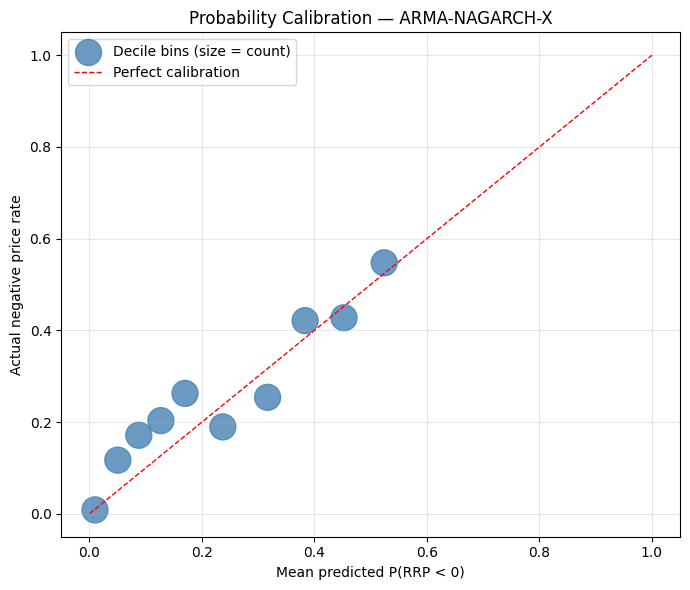

Calibration table:
 mean_predicted  actual_rate  count
         0.0099       0.0086   1752
         0.0505       0.1170   1752
         0.0878       0.1712   1752
         0.1271       0.2032   1752
         0.1700       0.2626   1752
         0.2372       0.1895   1752
         0.3168       0.2540   1752
         0.3835       0.4212   1752
         0.4527       0.4275   1752
         0.5241       0.5474   1752


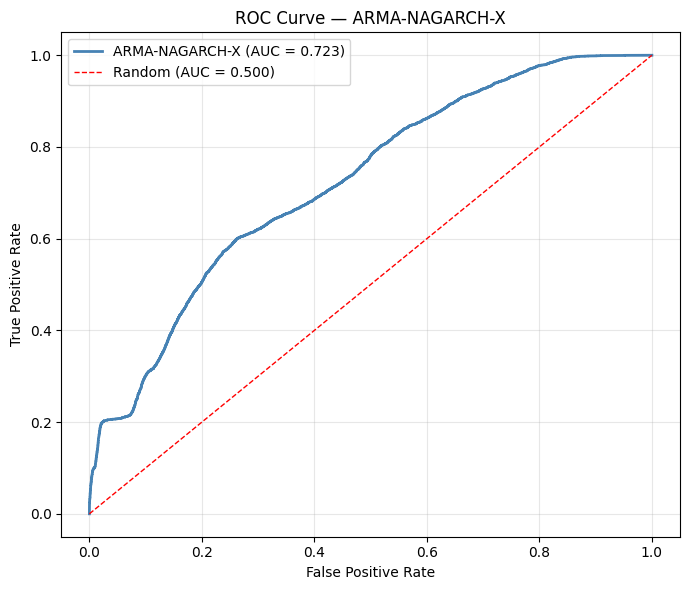

ROC-AUC: 0.7230


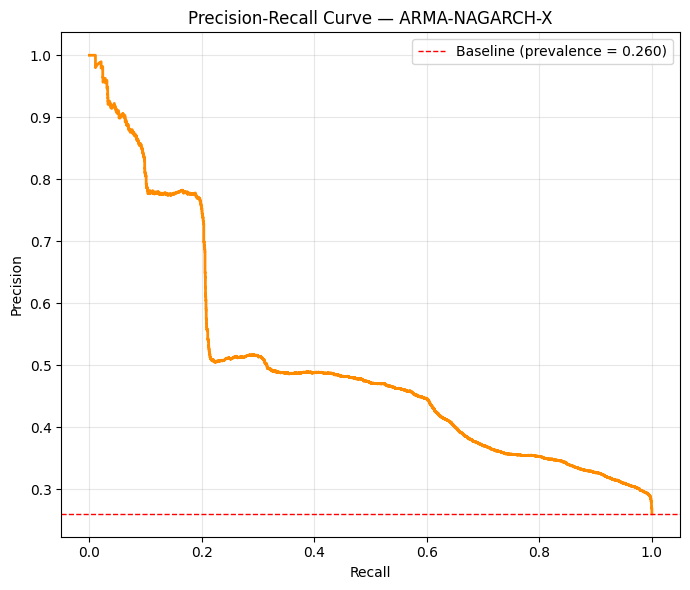


=== Classification Report (threshold = 0.5) ===
                precision    recall  f1-score   support

Positive price       0.77      0.96      0.86     12961
Negative price       0.64      0.21      0.31      4559

      accuracy                           0.76     17520
     macro avg       0.71      0.58      0.58     17520
  weighted avg       0.74      0.76      0.72     17520



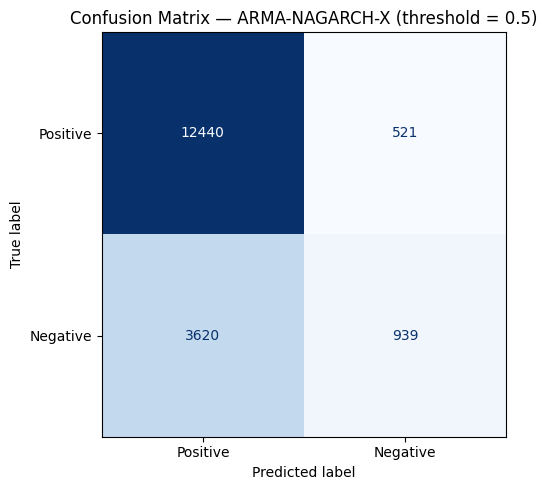


Threshold sensitivity:
 Threshold  Precision  Recall     F1  Predicted negative
       0.1     0.3263  0.9004 0.4790               12582
       0.2     0.3685  0.7065 0.4844                8740
       0.3     0.4279  0.6133 0.5041                6535
       0.4     0.4867  0.4170 0.4491                3906
       0.5     0.6432  0.2060 0.3120                1460


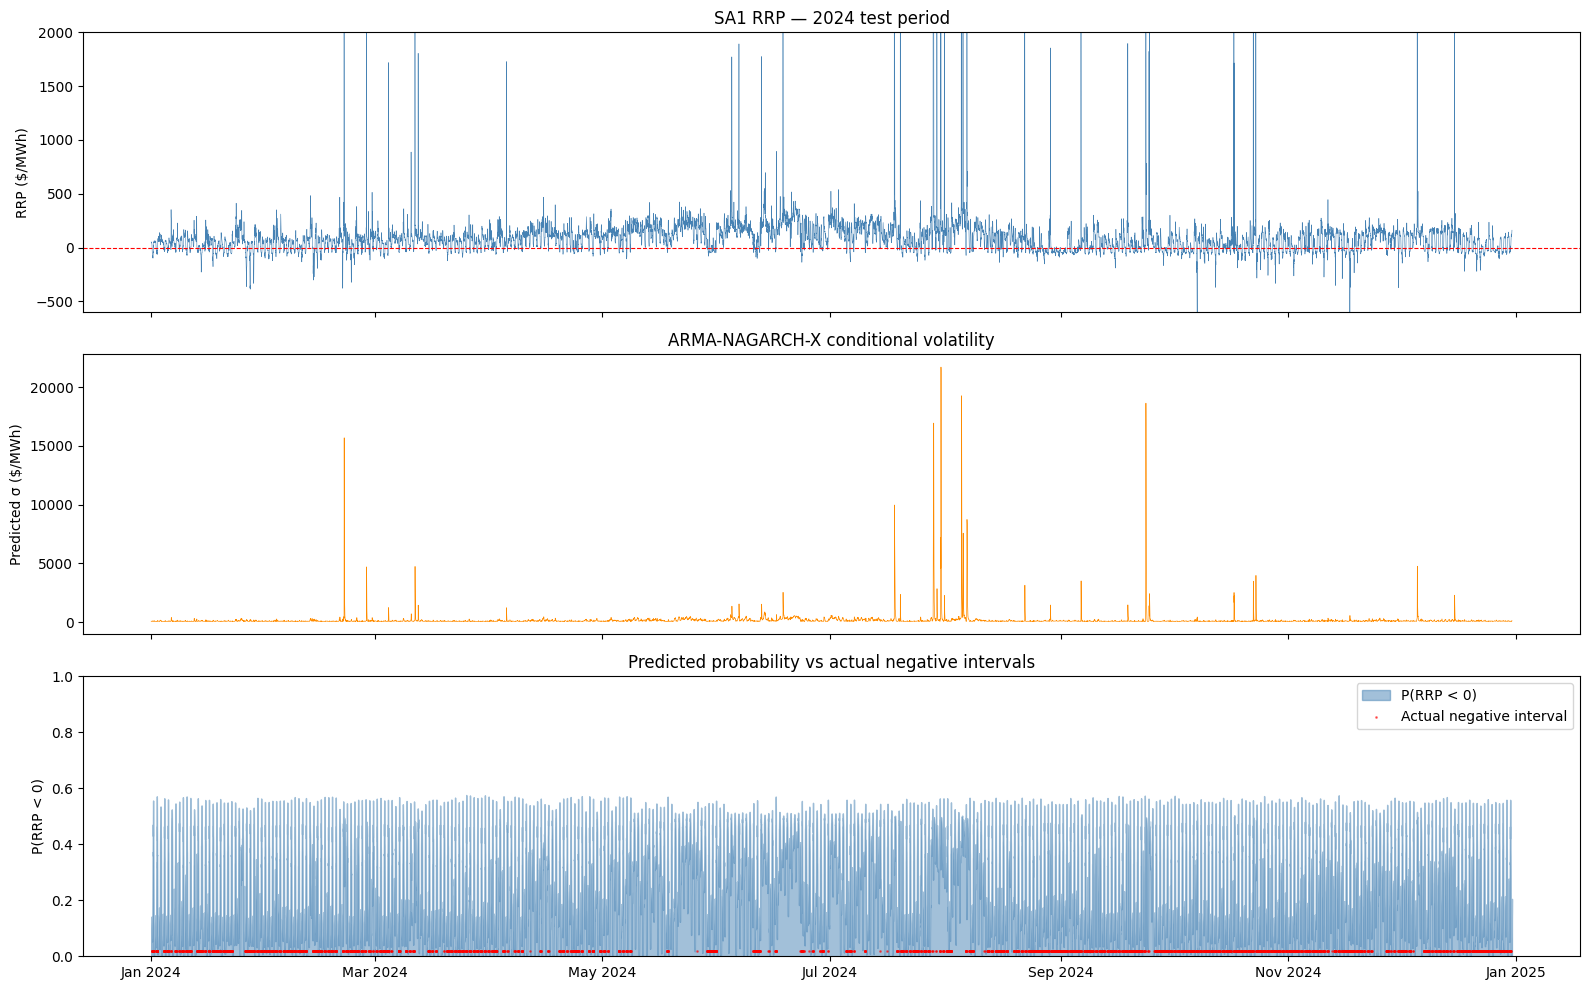


EVALUATION SUMMARY — ARMA-NAGARCH-X
Test intervals       : 17,520
Actual negative rate : 26.0%
Mean predicted P     : 23.6%
ROC-AUC              : 0.7230

At threshold = 0.5:
              precision    recall  f1-score   support

    Positive     0.7746    0.9598    0.8573     12961
    Negative     0.6432    0.2060    0.3120      4559

    accuracy                         0.7636     17520
   macro avg     0.7089    0.5829    0.5847     17520
weighted avg     0.7404    0.7636    0.7154     17520



In [24]:
# ============================================================
# Section 10 — Evaluation
# ============================================================

import matplotlib.dates as mdates

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

y_true = test_aligned['actual_negative'].values
y_prob = test_aligned['neg_price_prob'].values
y_pred = (y_prob >= 0.5).astype(int)

# ============================================================
# 10.1 Calibration
# ============================================================
# When model says P=0.3, do negative prices occur ~30% of the time?
# Bin predictions into deciles and check actual rate per bin

test_aligned['prob_decile'] = pd.qcut(
    test_aligned['neg_price_prob'], q=10,
    labels=False, duplicates='drop'
)

calibration = test_aligned.groupby('prob_decile').agg(
    mean_predicted=('neg_price_prob', 'mean'),
    actual_rate=('actual_negative', 'mean'),
    count=('actual_negative', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(calibration['mean_predicted'], calibration['actual_rate'],
           s=calibration['count'] / 5, color='steelblue', alpha=0.8,
           label='Decile bins (size = count)')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted P(RRP < 0)')
ax.set_ylabel('Actual negative price rate')
ax.set_title('Probability Calibration — ARMA-NAGARCH-X')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/calibration.png', bbox_inches='tight')
plt.show()

print('Calibration table:')
print(calibration[['mean_predicted', 'actual_rate', 'count']].round(4).to_string(index=False))

# ============================================================
# 10.2 ROC-AUC
# ============================================================
auc = roc_auc_score(y_true, y_prob)
fpr, tpr, _ = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ARMA-NAGARCH-X (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — ARMA-NAGARCH-X')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/roc_curve.png', bbox_inches='tight')
plt.show()

print(f'ROC-AUC: {auc:.4f}')

# ============================================================
# 10.3 Precision-Recall
# ============================================================
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_prob)
base_rate = y_true.mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, color='darkorange', linewidth=2)
ax.axhline(base_rate, color='red', linestyle='--', linewidth=1,
           label=f'Baseline (prevalence = {base_rate:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — ARMA-NAGARCH-X')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/precision_recall.png', bbox_inches='tight')
plt.show()

# ============================================================
# 10.4 Classification report at threshold = 0.5
# ============================================================
print('\n=== Classification Report (threshold = 0.5) ===')
print(classification_report(y_true, y_pred,
      target_names=['Positive price', 'Negative price']))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Positive', 'Negative']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — ARMA-NAGARCH-X (threshold = 0.5)')
plt.tight_layout()
plt.savefig('../../data/confusion_matrix.png', bbox_inches='tight')
plt.show()

# ============================================================
# 10.5 Threshold sensitivity
# ============================================================
rows = []
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_prob >= thresh).astype(int)
    if len(np.unique(pred)) < 2:
        continue
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    rows.append({'Threshold': thresh, 'Precision': prec,
                 'Recall': rec, 'F1': f1,
                 'Predicted negative': pred.sum()})

thresh_df = pd.DataFrame(rows)
print('\nThreshold sensitivity:')
print(thresh_df.round(4).to_string(index=False))

# ============================================================
# 10.6 Timeline plot
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Actual RRP
axes[0].plot(test_aligned['SETTLEMENTDATE'], test_aligned['RRP'],
             linewidth=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('RRP ($/MWh)')
axes[0].set_title('SA1 RRP — 2024 test period')
axes[0].set_ylim(-600, 2000)

# Predicted sigma
axes[1].plot(test_aligned['SETTLEMENTDATE'],
             test_aligned['predicted_sigma'],
             linewidth=0.5, color='darkorange')
axes[1].set_ylabel('Predicted σ ($/MWh)')
axes[1].set_title('ARMA-NAGARCH-X conditional volatility')

# Predicted probability vs actual negative events
axes[2].fill_between(test_aligned['SETTLEMENTDATE'],
                     test_aligned['neg_price_prob'],
                     alpha=0.5, color='steelblue',
                     label='P(RRP < 0)')
neg_events = test_aligned[test_aligned['actual_negative'] == 1]
axes[2].scatter(neg_events['SETTLEMENTDATE'],
                np.ones(len(neg_events)) * 0.02,
                color='red', s=1, alpha=0.5,
                label='Actual negative interval')
axes[2].set_ylabel('P(RRP < 0)')
axes[2].set_ylim(0, 1)
axes[2].set_title('Predicted probability vs actual negative intervals')
axes[2].legend(loc='upper right')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../../data/timeline.png', bbox_inches='tight')
plt.show()

# ============================================================
# 10.7 Summary
# ============================================================
print('\n' + '=' * 60)
print('EVALUATION SUMMARY — ARMA-NAGARCH-X')
print('=' * 60)
print(f'Test intervals       : {len(test_aligned):,}')
print(f'Actual negative rate : {y_true.mean():.1%}')
print(f'Mean predicted P     : {y_prob.mean():.1%}')
print(f'ROC-AUC              : {auc:.4f}')
print(f'\nAt threshold = 0.5:')
print(classification_report(y_true, y_pred,
      target_names=['Positive', 'Negative'], digits=4))
print('=' * 60)